# Vergleich: visuelle Filter


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr


In [2]:
DATA_DIR = Path('../../data')

INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '15_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_visual_filter.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(df[['influencer_type', 'filter_strength_prob', 'filter_strength_std']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ..\..\data\04_analysis_results\visual_features\15_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_visual_filter.csv
                filter_strength_prob                     filter_strength_std  \
                               count      mean       std               count   
influencer_type                                                                
ai                               250  0.992357  0.015994                 250   
real                             250  0.988890  0.029944                 250   

                                     
                     mean       std  
influencer_type                      
ai               0.010098  0.036868  
real             0.015115  0.044863  


In [3]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


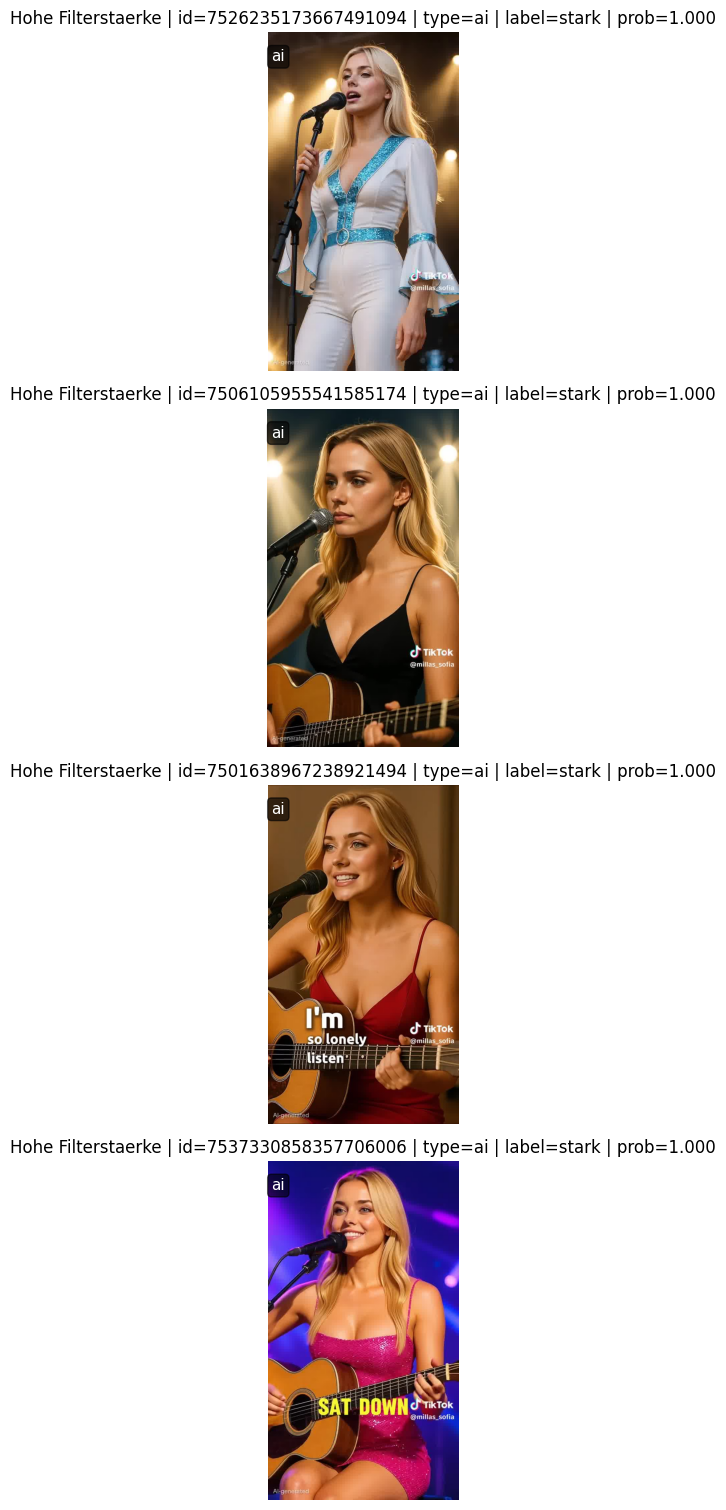

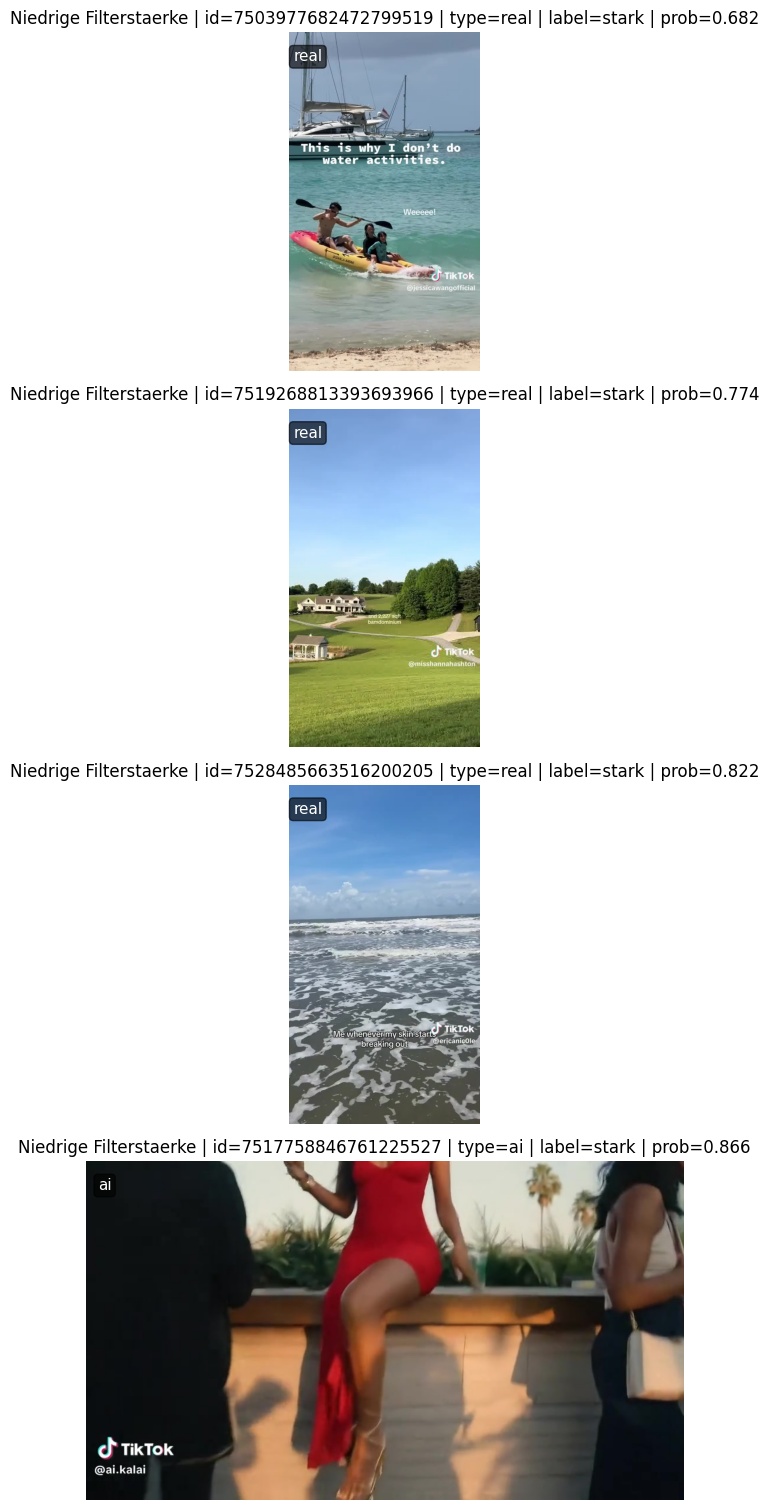

In [4]:
# Beispiele mit hoher und niedriger Filterstärke anzeigen
_df = df.dropna(subset=['filter_strength_prob']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        filt = row['filter_strength_prob']
        label = row.get('filter_strength_label', '')
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(f'{title} | id={vid} | type={inf} | label={label} | prob={filt:.3f}')

    plt.tight_layout()
    plt.show()

high_filter = pick_examples(_df.sort_values('filter_strength_prob', ascending=False), n=4)
low_filter = pick_examples(_df.sort_values('filter_strength_prob', ascending=True), n=4)

show_examples(high_filter, 'Hohe Filterstaerke')
show_examples(low_filter, 'Niedrige Filterstaerke')


In [5]:
summary = df.groupby('influencer_type')[['filter_strength_prob', 'filter_strength_std', 'processed_frame_count']].describe().round(3)
display(summary)

label_freqs = (
    df.groupby(['influencer_type', 'filter_strength_label'])
    .size()
    .unstack(fill_value=0)
)
display(label_freqs)


filter_strength_prob                                     \
                               count   mean    std    min    25%    50%   
influencer_type                                                           
ai                             250.0  0.992  0.016  0.866  0.993  0.997   
real                           250.0  0.989  0.030  0.682  0.993  0.996   

                            filter_strength_std         ...                \
                   75%  max               count   mean  ...    75%    max   
influencer_type                                         ...                 
ai               0.999  1.0               250.0  0.010  ...  0.003  0.325   
real             0.998  1.0               250.0  0.015  ...  0.006  0.332   

                processed_frame_count                                        \
                                count    mean    std  min   25%   50%   75%   
influencer_type                                                               
ai                              250.0  10.268  2.118  3.0   8.0  12.0  12.0   
real                            250.0  11.248  1.576  5.0  12.0  12.0  12.0   

                       
                  max  
influencer_type        
ai               12.0  
real             12.0  

[2 rows x 24 columns]

filter_strength_label,stark
influencer_type,
ai,250
real,250


c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

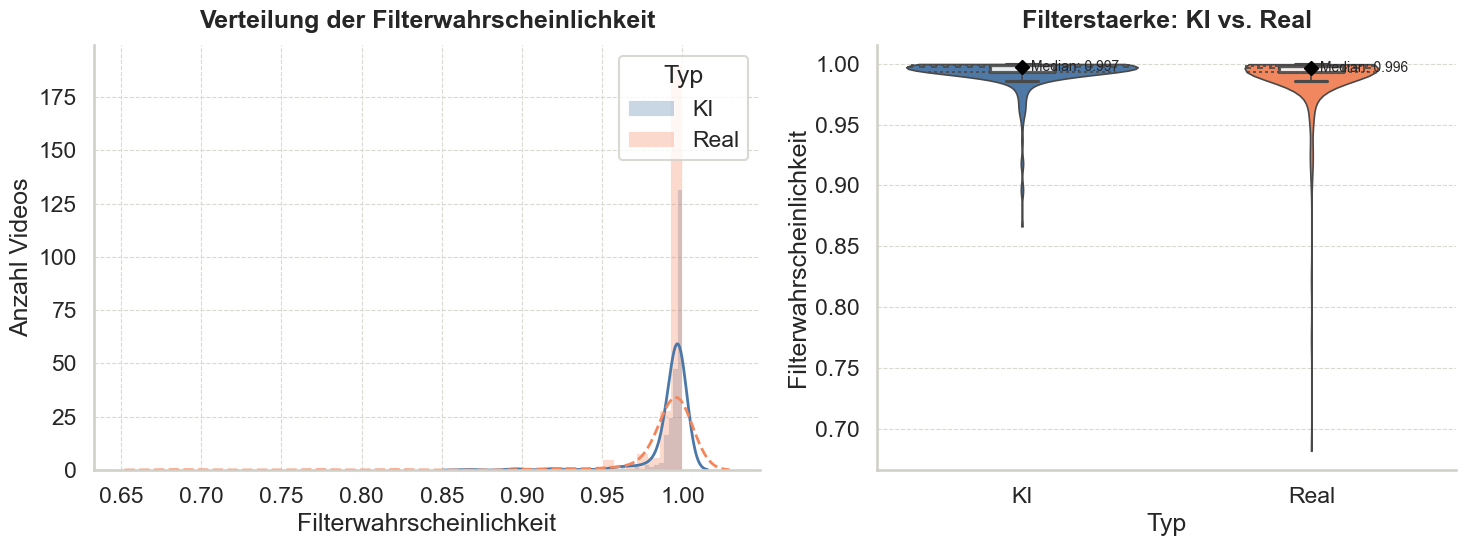

In [6]:
# Visualisierung der Filterwahrscheinlichkeit
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)
sns.set_palette(['#4C78A8', '#F5855B'])

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
LINESTYLE = {'KI': '-', 'Real': '--'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={'width_ratios': [1.15, 1]})

bins = 45
for grp in ['KI', 'Real']:
    vals = df_plot.loc[df_plot['typ'] == grp, 'filter_strength_prob'].dropna()

    sns.histplot(
        x=vals,
        bins=bins,
        stat='count',
        element='step',
        fill=True,
        alpha=0.30,
        color=PALETTE_COLOR[grp],
        edgecolor='white',
        linewidth=0.6,
        ax=axes[0],
        label=grp,
    )

    sns.kdeplot(
        x=vals,
        color=PALETTE_COLOR[grp],
        linestyle=LINESTYLE[grp],
        linewidth=2.0,
        ax=axes[0],
        legend=False,
    )

axes[0].set_title('Verteilung der Filterwahrscheinlichkeit', pad=12, weight='semibold')
axes[0].set_xlabel('Filterwahrscheinlichkeit')
axes[0].set_ylabel('Anzahl Videos')
axes[0].legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8')

sns.violinplot(
    data=df_plot,
    x='typ',
    y='filter_strength_prob',
    order=['KI', 'Real'],
    palette=PALETTE_COLOR,
    inner='quartile',
    cut=0,
    linewidth=1.2,
    saturation=0.95,
    ax=axes[1],
)

sns.boxplot(
    data=df_plot,
    x='typ',
    y='filter_strength_prob',
    order=['KI', 'Real'],
    width=0.22,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3},
    whiskerprops={'linewidth': 1.2},
    medianprops={'color': 'black', 'linewidth': 1.6},
    ax=axes[1],
)

med = df_plot.groupby('typ', dropna=False)['filter_strength_prob'].median().reindex(['KI', 'Real'])
axes[1].scatter([0, 1], med.values, c='black', s=45, zorder=4, marker='D')
for i, v in enumerate(med.values):
    axes[1].text(i + 0.03, v, f'Median: {v:.3f}', va='center', fontsize=10)

axes[1].set_title('Filterstaerke: KI vs. Real', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Filterwahrscheinlichkeit')

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


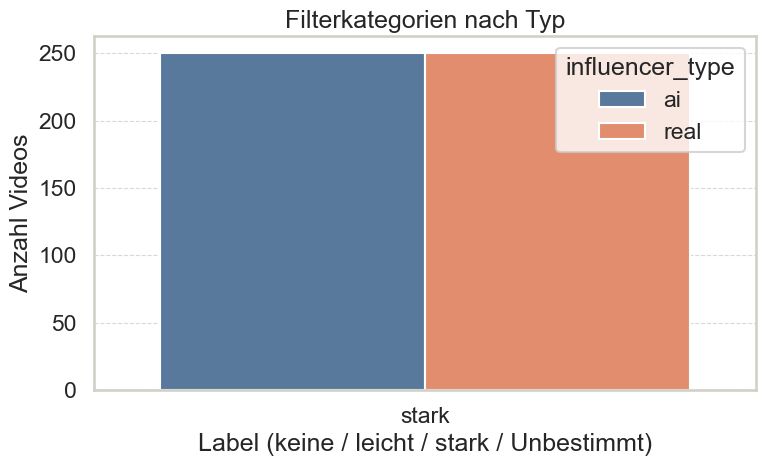

filter_strength_label,stark
influencer_type,
ai,1.0
real,1.0


In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='filter_strength_label', hue='influencer_type', palette=['#4C78A8', '#F5855B'])
plt.title('Filterkategorien nach Typ')
plt.xlabel('Label (keine / leicht / stark / Unbestimmt)')
plt.ylabel('Anzahl Videos')
plt.tight_layout()
plt.show()

freqs = (
    df.groupby(['influencer_type', 'filter_strength_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
)
display(freqs.round(3))


In [8]:
results = []
metric = 'filter_strength_prob'
ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()

if len(ai_vals) > 0 and len(real_vals) > 0:
    u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
    results.append({
        'metric': metric,
        'n_ai': len(ai_vals),
        'n_real': len(real_vals),
        'mean_ai': ai_vals.mean(),
        'mean_real': real_vals.mean(),
        'median_ai': ai_vals.median(),
        'median_real': real_vals.median(),
        'u_stat': u_stat,
        'u_p': u_p,
    })

results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,filter_strength_prob,250,250,0.9924,0.9889,0.9971,0.9964,35631.0,0.0067


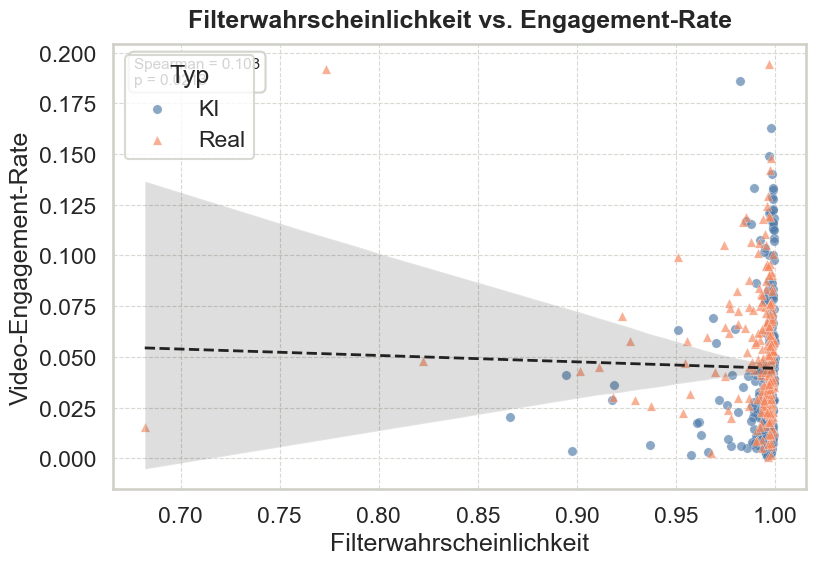

,Metrik,Spearman_rho,p_Wert
0,Filterwahrscheinlichkeit,0.103,0.0213


In [9]:
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)
sns.set_palette(['#4C78A8', '#F5855B'])

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}

corr_results = []
if 'video_engagement_rate' in df_plot.columns:
    metric_col = 'filter_strength_prob'
    metric_label = 'Filterwahrscheinlichkeit'

    rho, pval = spearmanr(df_plot[metric_col], df_plot['video_engagement_rate'], nan_policy='omit')
    corr_results.append({'Metrik': metric_label, 'Spearman_rho': rho, 'p_Wert': pval})

    fig, ax = plt.subplots(figsize=(8.5, 6))
    for grp in ['KI', 'Real']:
        sub = df_plot[df_plot['typ'] == grp]
        sns.scatterplot(
            data=sub,
            x=metric_col,
            y='video_engagement_rate',
            color=PALETTE_COLOR[grp],
            marker=MARKER[grp],
            edgecolor='white',
            linewidth=0.3,
            s=45,
            alpha=0.65,
            ax=ax,
            label=grp,
        )

    sns.regplot(
        data=df_plot,
        x=metric_col,
        y='video_engagement_rate',
        scatter=False,
        ci=95,
        line_kws={'color': '#222222', 'linewidth': 2.0, 'linestyle': '--'},
        ax=ax,
    )

    ax.set_title(f'{metric_label} vs. Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel(metric_label)
    ax.set_ylabel('Video-Engagement-Rate')

    ax.text(
        0.03, 0.97,
        f'Spearman = {rho:.3f}\np = {pval:.4f}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.9),
    )

    ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate column not available; skipping correlation analysis.')

corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)


In [10]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Mittelwertunterschied')
    print(f"- Visuelle Filter (filter_strength_prob): Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Ein signifikanter Gruppenunterschied weist auf systematisch unterschiedliche Nachbearbeitung hin ({direction}).")
else:
    print('- Keine ausreichenden Daten für Mann-Whitney-Test vorhanden.')

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']
    p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement-Zusammenhang: Spearman ist {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang; positives Vorzeichen deutet auf mehr Engagement bei höherer Filterwahrscheinlichkeit hin.")


Kurzinterpretation:
- Visuelle Filter (filter_strength_prob): Mann-Whitney ist signifikant (p=0.0067). Interpretation: Ein signifikanter Gruppenunterschied weist auf systematisch unterschiedliche Nachbearbeitung hin (höher bei KI).
- Engagement-Zusammenhang: Spearman ist signifikant (rho=0.103, p=0.0213). Interpretation: positiver Zusammenhang; positives Vorzeichen deutet auf mehr Engagement bei höherer Filterwahrscheinlichkeit hin.
